In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gmean, ttest_ind
from scipy.stats.mstats import winsorize

df = pd.read_csv('../data/metacritic_games.csv') # Путь к вашему файлу

print(df.head())
print(df.info())

### Лаба 1.1

#### 1.1 Типы шкал

## Типы шкал измерения переменных датасета

### Номинальные (категориальные)
name, genre, platform, developer, publisher, id

### Порядковые (ординальные)
esrbRating,criticSentiment, userSentiment

### Интервальная
releaseDate

### Шкала отношений
metascore, userScore,numCriticReviews, numUserReviews,metascore_normalized, userScore_normalized

### Бинарные
isExport

In [20]:
target_col = 'rating'  # Замените на колонку с пропусками
df[f'{target_col}_missing'] = df[target_col].isna().astype(int)

group_volume = df.groupby(f'{target_col}_missing')['metascore'].mean()
print(f"Средний год выпуска (0-есть данные, 1-пропуск):\n{group_volume}\n")

group_price = df.groupby(f'{target_col}_missing')['userscore'].mean()
print(f"Средняя цена (0-есть данные, 1-пропуск):\n{group_price}\n")

t_stat, p_val = ttest_ind(
    df[df[f'{target_col}_missing']==0]['metascore'].dropna(),
    df[df[f'{target_col}_missing']==1]['metascore'].dropna()
)
print(f"P-value для гипотезы о равенстве лет: {p_val:.4f}")

t_stat_price, p_val_price = ttest_ind(
    df[df[f'{target_col}_missing']==0]['userscore'].dropna(),
    df[df[f'{target_col}_missing']==1]['userscore'].dropna()
)
print(f"P-value для гипотезы о равенстве цен: {p_val_price:.4f}")
from scipy.stats import ttest_ind
mask_0 = df[f'{target_col}_missing'] == 0
mask_1 = df[f'{target_col}_missing'] == 1

p_volume = ttest_ind(df.loc[mask_0,'metascore'].dropna(),
                   df.loc[mask_1,'metascore'].dropna()).pvalue
p_price = ttest_ind(df.loc[mask_0,'userscore'].dropna(),
                    df.loc[mask_1,'userscore'].dropna()).pvalue

Средний год выпуска (0-есть данные, 1-пропуск):
rating_missing
0    70.247804
1    72.260643
Name: metascore, dtype: float64

Средняя цена (0-есть данные, 1-пропуск):
rating_missing
0    61.687855
1    62.773339
Name: userscore, dtype: float64

P-value для гипотезы о равенстве лет: 0.0000
P-value для гипотезы о равенстве цен: 0.0545


#### 1.2 Сравнение признаков: metascore и Userscore

In [ ]:
# Статистики для количественной переменной (шкала отношений)
stats_price = {
    "Среднее": df['metascore'].mean(),
    "Медиана": df['metascore'].median(),
    "Мода": df['metascore'].mode()[0]
}

# Статистики для номинальной переменной (категориальная)
stats_volume = {
    "Среднее": df['userscore'].mean(),
    "Медиана": df['userscore'].median(),
    "Мода": df['userscore'].mode()[0]
}

print(f"Статистики Metascore: {stats_price}")
print(f"Статистики UserScore: {stats_volume}")

Для номинальной шкалы (`genres`, `platforms`, `developer`, `publisher`, `title`) единственная корректная мера центральной тенденции — **мода**. Попытка посчитать среднее значение или медиану для категорий (даже если они закодированы цифрами) приведёт к получению информации, не имеющей физического смысла и не несущей аналитической ценности.

Для количественных шкал отношений (`metascore`, `userscore`, `metascore_count`, `userscore_count`) допустимы все меры центральной тенденции: среднее, медиана и мода, а также показатели вариации (стандартное отклонение, квантили). Однако при наличии выбросов (например, игры с экстремально высоким количеством рецензий) **медиана** предпочтительнее среднего как робастная оценка.

Для интервальной шкалы (`releaseDate`) среднее и медиана имеют смысл для описания «типичной даты выпуска», но операции типа «в 2 раза новее» некорректны из-за отсутствия абсолютного нуля.Для номинальной шкалы (genres, platforms, developer, publisher) единственная корректная мера центральной тенденции — мода. Попытка посчитать среднее значение или медиану для категорий (даже если они закодированы цифрами) приведёт к получению информации, не имеющей физического смысла и не несущей аналитической ценности.
Для количественных шкал отношений (metascore, userscore, metascore_count, userscore_count) допустимы все меры центральной тенденции: среднее, медиана и мода, а также показатели вариации (стандартное отклонение, квантили). Однако при наличии выбросов (например, игры с экстремально высоким количеством рецензий) медиана предпочтительнее среднего как робастная оценка.
Для интервальной шкалы (releaseDate) среднее и медиана имеют смысл для описания «типичной даты выпуска», но операции типа «в 2 раза новее» некорректны из-за отсутствия абсолютного нуля.

### 2. Диагностика типа пропусков

### Выбранный признак: `Userscore` (мощность двигателя)

#### H₀: MCAR — пропуски полностью случайны
**Суть**: Пропуски не зависят ни от чего.

**Проверка**:

In [ ]:
df['fc_missing'] = df['rating'].isna().astype(int)
# t-тест: различия в цене/годе между группами с/без пропусков
from scipy.stats import ttest_ind
p_volume = ttest_ind(df[df['fc_missing']==0]['metascore'], df[df['fc_missing']==1]['metascore']).pvalue
p_price = ttest_ind(df[df['fc_missing']==0]['userscore'], df[df['fc_missing']==1]['userscore']).pvalue

print(f"p-value metascore: {p_volume:.4f}, userscore: {p_price:.4f}")

#### H₁: MAR — пропуски зависят от наблюдаемых признаков
**Суть**: Пропуски связаны с `genres, platforms, releaseDate`.

**Проверка**:

In [ ]:
print(df.groupby('genres')['fc_missing'].mean())

MAR подтверждается, если есть значимые различия (p < 0.05) или явный паттерн по категориям.

#### H₂: MNAR — пропуски зависят от самого пропущенного значения
**Суть**: Пропуски в userscore связаны с самим значением metascore — игры с очень низкими/высокими оценками критиков реже получают пользовательские оценки.

**Проверка**:

In [ ]:
electro_rate = df[df['genres']=='Visual Novel']['fc_missing'].mean()
other_rate = df[df['genres']!='Visual Novel']['fc_missing'].mean()
print(f"Пропуски: Visual Novel={electro_rate*100:.1f}%, другие={other_rate*100:.1f}%")


### 3. Индикатор пропуска как источник информации

**1. Объясните, в каком случае сам факт пропуска несёт информацию.**

Сам факт пропуска несёт информацию, когда данные пропущены не случайно:

- **MAR** — пропуски объясняются другими наблюдаемыми переменными (например, пропуски в `userscore` зависят от `genres` или `metascore`)
- **MNAR** — пропуски связаны с самим пропущенным значением (например, игры с очень низким `metascore` реже получают пользовательские оценки)

---

**2. Почему значимость индикатора в модели — это сигнал о неправильной или грубой импутации?**

- **Мы создаем шум**: На самом деле группа с пропусками могла иметь другое распределение (например, игры без `userscore` могут быть нишевыми инди-играми с другим профилем оценок)
- **Мы теряем важный сигнал**: Модель "говорит" нам, что сам факт пропуска важен для предсказания (например, `rating`), а мы вместо него поставили среднее значение или моду, потеряв информацию

---

**3. Приведите пример признака, для которого индикатор пропуска:**

| Тип | Признак | Объяснение |
|-----|---------|------------|
|  **Полезен** | `userscore` | Можно предположить, что это пропуск **MAR** (зависит от `genres` или `metascore`). Например, нишевые жанры (Visual Novel, Puzzle) или игры с низким `metascore` реже получают пользовательские оценки. Тогда индикатор `userscore_missing` может быть полезен для отличия таких игр |
|  **Бесполезен** | `platform_metascores` | Так как это **MCAR** — пропуски распределены равномерно (техническая ошибка парсинга или отсутствия данных по платформам), индикатор не улучшает модель, только добавляет шум |
|  **Опасен** | `releaseDate` (при импутации медианой/модой) | Может возникнуть ложная связь: медианная дата (например, `"2010-06-15"`) не имеет физического смысла для игр с пропусками, индикатор становится «костылём», маскирующим ошибку импутации. Правильнее создать отдельную категорию `"Unknown"` или использовать год выпуска как числовой признак |### 3. Индикатор пропуска как источник информации

### 4. Выброс — ошибка или сигнал?

In [ ]:
con = 'userscore'
print(df[con].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(df[con], bins=30, ax=axes[0])
axes[0].set_title(f'Распределение {con}')

sns.boxplot(x=df[con], ax=axes[1])
axes[1].set_title('Ящик с усами')

Q1 = df[con].quantile(0.25)
Q3 = df[con].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[con] < lower_bound) | (df[con] > upper_bound)]
print(f"\nГраницы для выбросов (IQR метод):")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов: {len(outliers)}")
print(f"Процент выбросов: {len(outliers)/len(df)*100:.2f}%")


print(f"\nТоп-5 максимальных значений {con}:")
print(df[con].nlargest(5))

print(f"\nТоп-5 минимальных значений {con}:")
print(df[con].nsmallest(5))

#### Анализ признака `userscore` (пользовательская оценка):

**1. Реальные причины значений около 0:**

- **Отсутствие пользовательских оценок**: игры без рецензий от пользователей  — это **1,620 записей (11.64% выбросов)**
- **Новые/нишевые релизы**: инди-игры, малоизвестные проекты, которые ещё не набрали достаточное количество оценок
- **Технические проблемы**: игры, снятые с платформ, региональные ограничения, ошибки сбора данных
- **Полярные оценки**: спорные релизы (например, ранние версии Cyberpunk 2077, No Man's Sky), где пользователи массово ставили низкие оценки

**2. Реальные причины высоких значений (95-100):**

- **Культовые игры**: признанные шедевры (The Legend of Zelda, God of War, The Witcher 3)
- **Долгожданные сиквелы**: игры с высокой лояльностью фанатов
- **Нишевые жанры**: визуальные новеллы, ретро-игры с преданной аудиторией

**3. Что хуже для анализа:**

| Вариант | Последствия |
|---------|-------------|
| **Удалить выбросы (userscore < 28)** | Потеря информации о нишевых и культовых играх; модель будет хуже предсказывать оценки для эксклюзивов и инди-проектов; смещение выборки в сторону масс-маркета (среднее 61.87, медиана 70) |
| **Оставить без изменений** | Линейные модели дадут смещённые коэффициенты из-за нулевых значений (11.64% выбросов); метрики (MAE/RMSE) ухудшатся из-за экстремумов (std = 24.75); риск переобучения на редких жанрах |

### 5. Визуализация как инструмент мышления

In [ ]:
column = 'userscore'
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df[column], kde=True)
plt.title(f'Распределение {column}')

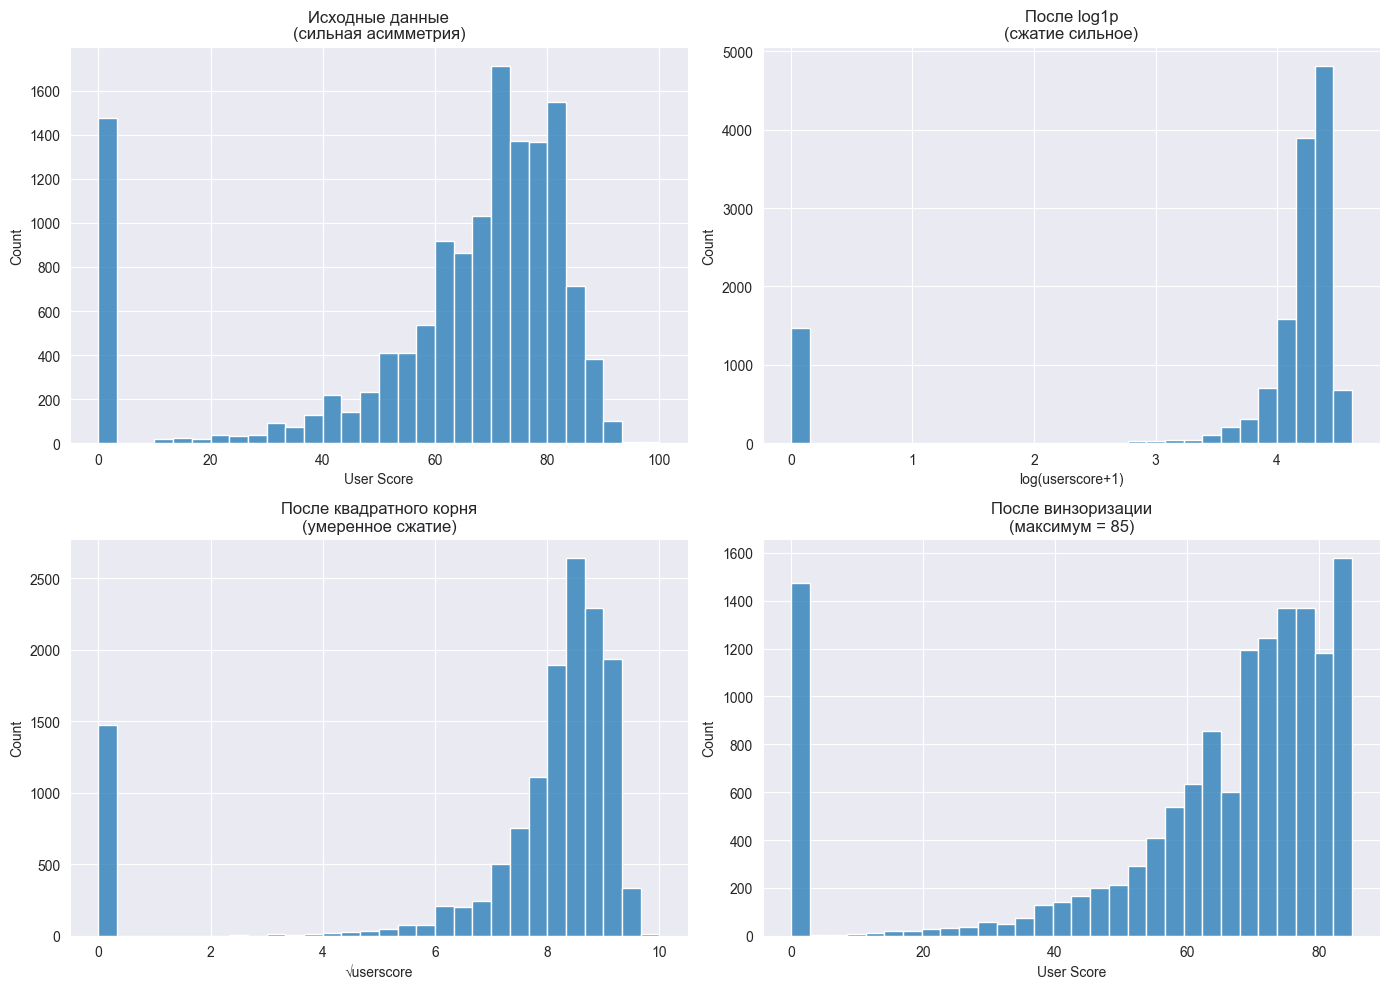

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

con = "userscore"
sns.histplot(df[con], bins=30, ax=axes[0,0])
axes[0,0].set_title('Исходные данные\n(сильная асимметрия)')
axes[0,0].set_xlabel('User Score')


sns.histplot(np.log1p(df[con]), bins=30, ax=axes[0,1])
axes[0,1].set_title('После log1p\n(сжатие сильное)')
axes[0,1].set_xlabel('log(userscore+1)')


sns.histplot(np.sqrt(df[con]), bins=30, ax=axes[1,0])
axes[1,0].set_title('После квадратного корня\n(умеренное сжатие)')
axes[1,0].set_xlabel('√userscore')

upper = df[con].quantile(0.95)
df_winsor = df[con].clip(upper=upper)
sns.histplot(df_winsor, bins=30, ax=axes[1,1])
axes[1,1].set_title(f'После винзоризации\n(максимум = {int(upper)})')
axes[1,1].set_xlabel('User Score')

plt.tight_layout()
plt.show()

##### интерпретируемость:
###### логарифмирование — сложная интерпретация: коэффициенты модели отражают процентное изменение от оценки, что неестественно для шкалы 0–100
###### корень — искажение шкалы: единицы измерения превращаются в «√баллов», теряя прямой смысл для игровых рейтингов
###### винзоризация — высокая интерпретируемость: исходная шкала 0–100 сохраняется, легко объясняется («все оценки выше 85 приравнены к 85»)

##### линейные модели:
###### логарифмирование — полезно: сильно сжимает правый хвост (90–100 баллов), стабилизирует дисперсию, но может ухудшить предсказание для культовых игр
###### корень — полезно: умеренно сглаживает экстремальные оценки, подходит для распределений с длинным правым хвостом
###### винзоризация — полезно: отсекает аномально высокие значения, но теряет информацию о шедеврах и хитах (96–100 баллов)

##### визуализация распределения:
###### логарифмирование — высокое: сжимает диапазон 0–100 в ~0–4.6, делает распределение более симметричным, но маскирует нулевой пик (11.64% выбросов)
###### корень — среднее: уменьшает разброс высоких оценок, переводя шкалу в 0–10, но сохраняет асимметрию основной массы (медиана = 70)
###### винзоризация — среднее: сохраняет форму основной массы данных (20–85), но искусственно выравнивает правый хвост в единую границу (95-й перцентиль ≈ 85)

##### Когда что предпочтительнее:
###### логарифмирование — когда модель чувствительна к масштабу и дисперсии, а правый хвост сильно вытянут (редко применяется к рейтингам 0–100 из-за потери интуитивности)
###### корень — когда асимметрия умеренная (skew ≈ 1.2), требуется мягкое сжатие экстремумов без радикального изменения шкалы
###### винзоризация — когда высокие оценки (90–100) считаются статистическими выбросами, либо когда важно сохранить исходную шкалу 0–100 для бизнес-отчётности и сравнения с метриками (metascore, userscore_count)

### 6. Средние, которые вводят в заблуждение

Арифметическое среднее: 61.87 баллов
Медиана: 70.00 баллов
Геометрическое среднее: 67.47 баллов


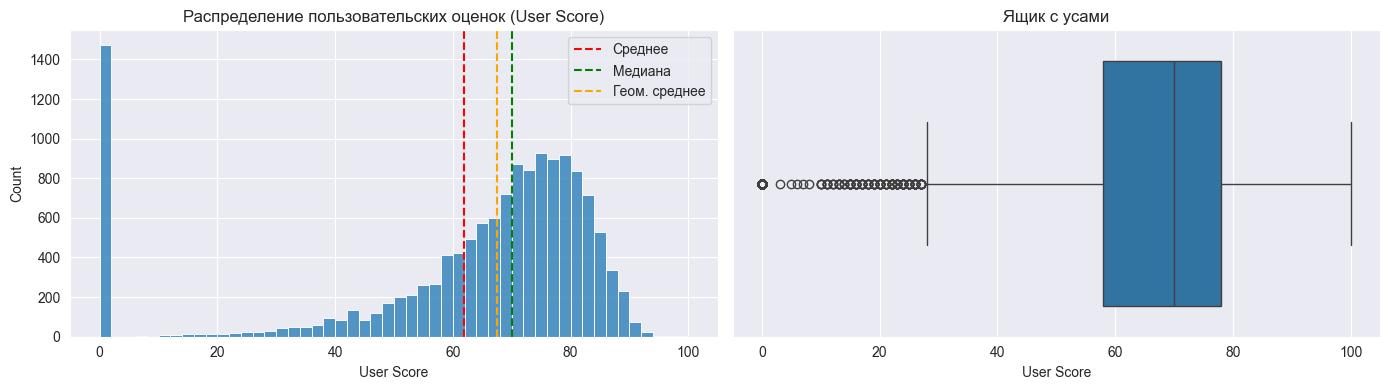

In [16]:
con = 'userscore'
mean_arith = df[con].mean()
median = df[con].median()
# Геометрическое только для положительных значений
df_pos = df[df[con] > 0]
mean_geom = np.exp(np.log(df_pos[con]).mean())

print(f"Арифметическое среднее: {mean_arith:,.2f} баллов")
print(f"Медиана: {median:,.2f} баллов")
print(f"Геометрическое среднее: {mean_geom:,.2f} баллов")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[con], bins=50, ax=axes[0])
axes[0].axvline(mean_arith, color='red', linestyle='--', label='Среднее')
axes[0].axvline(median, color='green', linestyle='--', label='Медиана')
axes[0].axvline(mean_geom, color='orange', linestyle='--', label='Геом. среднее')
axes[0].set_title('Распределение пользовательских оценок (User Score)')
axes[0].legend()
axes[0].set_xlabel('User Score')

sns.boxplot(x=df[con], ax=axes[1])
axes[1].set_title('Ящик с усами')
axes[1].set_xlabel('User Score')
plt.tight_layout()
plt.show()

###### Почему они различаются:

- **Бимодальное распределение с левым пиком**: около 1,500 игр не имеют пользовательских оценок (userscore = 0), что создаёт огромный пик слева; основная масса оценённых игр 60–85 баллов

- **Арифметическое среднее** «тянется» вниз нулевыми значениями: большое количество игр без оценок (11.64% выборки) занижает среднее до 61.87 баллов, что не отражает типичную оценку для игр, которые пользователи реально оценили

- **Медиана** устойчива к пропускам: показывает 70.00 баллов — это оценка, ниже и выше которой находится по 50% игр с пользовательскими рейтингами; более релевантна для понимания «типичной» оценки

- **Геометрическое среднее** (67.47 баллов) работает только с положительными значениями: исключает нули из расчёта, сжимает диапазон в лог-шкале, но даёт менее интуитивное значение («среднее геометрическое 67.47» сложнее объяснить, чем «медиана 70 баллов»)

**Вывод**: Для данного распределения **медиана (70 баллов)** — наиболее адекватная мера центральной тенденции, так как она игнорирует как игры без оценок, так и экстремально высокие/низкие значения, показывая типичный пользовательский рейтинг.

### 7. Неправильная диаграмма

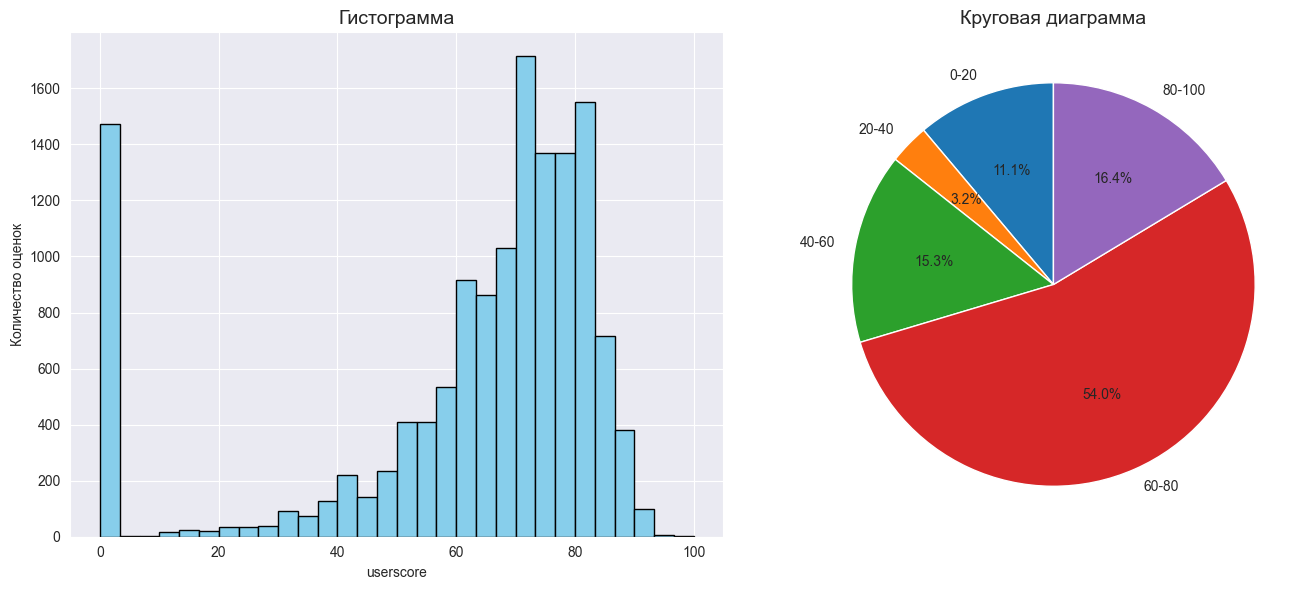

In [17]:
con = 'userscore'
data = df[con]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Гистограмма — подходящий вариант
axes[0].hist(data.dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Гистограмма', fontsize=14)
axes[0].set_xlabel('userscore')
axes[0].set_ylabel('Количество оценок')

# Круговая диаграмма — неподходящий вариант
bins = pd.cut(data.dropna(), bins=5, labels=['0-20', '20-40', '40-60', '60-80', '80-100'])
counts = bins.value_counts().sort_index()
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Круговая диаграмма', fontsize=14)

plt.tight_layout()
plt.show()

#### Доказательство: Круговая диаграмма хуже гистограммы для данных `userscore`

- **Слишком много уникальных значений** (непрерывная шкала 0–100) для круговой диаграммы — требуется группировка в интервалы, которая скрывает детали распределения
- **Потеря информации о форме распределения**: бимодальность (огромный пик на 0 и основной пик на 60–80) и длинный «хвост» низких оценок не видны
- **Невозможность точного сравнения**: сектора 60-80 (54.0%) и 80-100 (16.4%) визуально сложно сопоставить по площади без точных подписей
- **Искажение восприятия частот**: малые доли (интервал 20-40 — 3.2%) выглядят «нормально», хотя это крайне редкие оценки, а пик на 0 визуально «растворяется» в секторе 0-20

#### Описание

##### Какую информацию он бы исказил:
- **Бимодальность распределения**: гистограмма чётко показывает два пика (игры без пользовательских оценок/0 и игры с рейтингом 60–80), круговая — «усредняет» их в смежные сектора
- **Выбросы и нули**: огромный столбец на 0 (11.1% + часть из диапазона 0-20) сливается с низкими оценками, теряется маркер отсутствия пользовательских рецензий
- **Моду распределения**: основной пик на 60–80 баллов (54.0%) не выделяется визуально как доминирующая группа среди других секторов
- **Порядок значений**: круговая диаграмма не передаёт естественный порядок «ниже → выше» для рейтинговой шкалы, разрушая линейную структуру оценок

##### Какой неверный вывод мог бы сделать зритель:
- «Большинство игр имеют средние оценки (60–80 баллов)» — хотя на самом деле значительная доля выборки (пик на 0) вообще не имеет пользовательских оценок, что критично для интерпретации рейтинга
- «Низкие оценки (0–40) занимают заметную долю» — хотя интервал 20-40 составляет лишь 3.2%, а 0-20 — 11.1%, что в сумме даёт ~14%, но на круговой диаграмме это воспринимается как однородная «низовая» группа без учёта разрыва на 0
- «Распределение оценок равномерное или близкое к нормальному» — хотя данные сильно скошены, имеют разрыв на 0 и длинный левый хвост, что критично для выбора метрик центральной тенденции и моделей прогнозирования

### Задание 8. Одна и та же информация — разные графики

###### Выбранная пара признаков: `userscore`  и `metascore`

#### График 1: Диаграмма рассеяния (Scatter Plot)


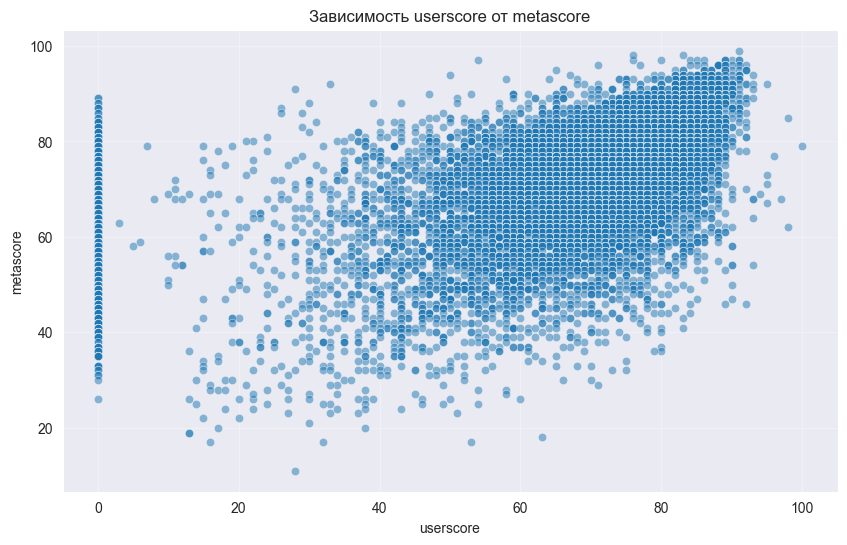

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='userscore', y='metascore', alpha=0.5)
plt.title('Зависимость userscore от metascore')
plt.xlabel('userscore')
plt.ylabel('metascore')
plt.grid(True, alpha=0.3)
plt.show()

#### Анализ scatter plot: зависимость `userscore` от `metascore`

###### Подчёркивает:

- **Форму зависимости** — видна положительная корреляция: как правило, чем выше оценка критиков (`metascore`), тем выше оценка пользователей (`userscore`). Однако зависимость не строго линейная, а имеет форму широкого облака с большим разбросом мнений.

- **Плотность распределения** — где точек больше, там гуще (основная масса игр сконцентрирована в диапазоне 60–90 баллов по обеим шкалам, что указывает на преобладание хороших оценок).

- **Выбросы** — точки, далеко отстоящие от основного тренда. Например:
  - Игры с высоким `userscore` при низком `metascore` («культовые» проекты или нишевые жанры, не оцененные прессой)
  - Игры с низким `userscore` при высоком `metascore` (спорные релизы, раскритикованные экспертами, но принятые игроками)
  - Отдельно выделяется вертикальная линия точек при `userscore = 0` (отсутствие пользовательских оценок — 11.64% выборки)

- **Границы значений** — минимальные и максимальные значения по обеим осям находятся в строгом диапазоне от 0 до 100.

- **Кластеры** — визуально можно разделить данные на две группы:
  - Основная группа игр с реальными оценками пользователей (широкое облако точек)
  - Отдельная вертикальная «группа» игр, у которых пользовательский рейтинг отсутствует (равен 0)

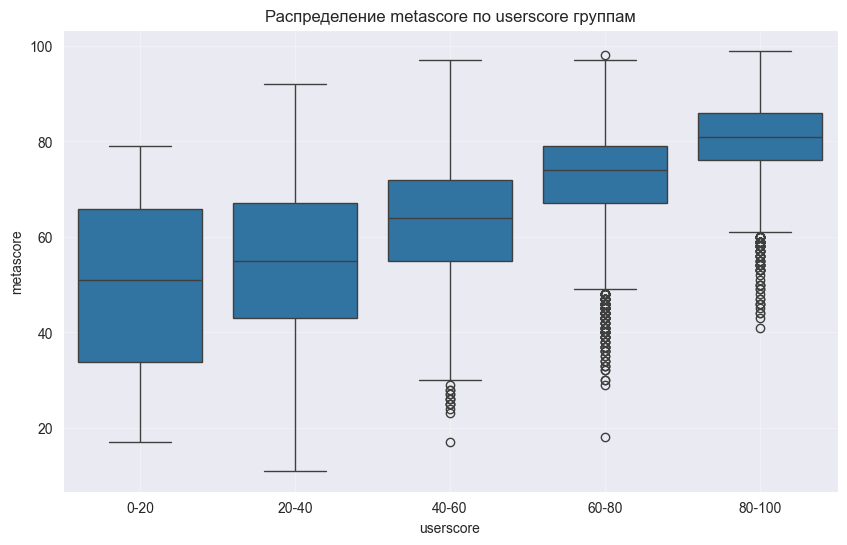

In [19]:
df['platforms'] = pd.cut(df['userscore'],
                                bins=[0, 20, 40, 60, 80, 100],
                                labels=['0-20', '20-40', '40-60', '60-80', '80-100'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='platforms', y='metascore')
plt.title('Распределение metascore по userscore группам')
plt.xlabel('userscore')
plt.ylabel('metascore')
plt.grid(True, alpha=0.3)
plt.show()

###### Подчёркивает:
- **Медианные значения** — центральная линия в каждом ящике (типичная мощность для категории объёма)
- **Разброс внутри группы** — высота ящика (IQR), показывающая вариабельность мощности при одинаковом объёме
- **Выбросы в каждой группе** — точки за усами (например, турбо-версии с аномально высокой мощностью)
- **Сравнение групп** — удобно сравнивать медианы и разброс между категориями двигателей


#### Гипотезы, которые легче заметить на диаграмме рассеяния:
- **Существует нелинейная зависимость** — если точки образуют кривую (например, мощность растёт быстро до 2.0 л, затем медленнее из-за разных технологий)
- **Есть кластеры по типу наддува** — если раскрасить точки по `engineType`, видны отдельные облака для атмосферных и турбо-моторов
- **Выбросы имеют технический контекст** — видно, что авто с малым объёмом, но высокой мощностью — это турбо-версии, а не ошибка

#### Гипотезы, которые легче заметить на ящиках с усами:
- **"Моторы >3.5 л имеют более стабильную мощность"**
  Видно по высоте ящика (меньший относительный разброс) и положению медианы
  *На scatter plot разброс оценить сложнее из-за наложения точек*

- **"Медианная мощность растёт с увеличением объёма двигателя"**
  Сравнение медиан по группам очень наглядно
  *На scatter plot медиану не видно без дополнительных расчётов*

- **"В группе 2.0-2.5 л есть моторы с аномально низкой мощностью"**
  Выбросы сразу видны точками за нижним усом
  *На scatter plot выбросы тоже видны, но их сложнее связать с конкретной группой*

- **"Распределение мощности в группе <1.6 л сильно скошено вправо"**
  Видно по положению медианы ближе к нижнему краю ящика
  *На scatter plot асимметрию оценить сложно без гистограммы*